import nltk
import matplotlib.pyplot as plt
import re
from nltk.tokenize import word_tokenize


%matplotlib inline


In [23]:
def get_text_data(filename):
    with open(filename, 'r', encoding='utf-8') as f:
        raw = f.read()
   
    tokens = raw.lower().split() 
    return tokens, raw

tokens_1, raw_1 = get_text_data('1x1-litz.txt')
tokens_2, raw_2 = get_text_data('1x2-litz.txt')

print(f"Loaded {len(tokens_1)} tokens from 1x1 and {len(tokens_2)} tokens from 1x2.")

Loaded 1979 tokens from 1x1 and 2564 tokens from 1x2.


In [24]:
def lexical_diversity(text):
    if not text:
        return 0
    return len(set(text)) / len(text)

print(f"Arthur's Eyes Diversity: {lexical_diversity(tokens_1):.4f}")
print(f"Bad Hair Day Diversity: {lexical_diversity(tokens_2):.4f}")

Arthur's Eyes Diversity: 0.4037
Bad Hair Day Diversity: 0.3814


In [26]:
# Use regex to find text inside parentheses
actions_1 = re.findall(r'\((.*?)\)', raw_1)
actions_2 = re.findall(r'\((.*?)\)', raw_2)

print(f"Stage Directions in 1x1: {len(actions_1)}")
print(f"Stage Directions in 1x2: {len(actions_2)}")
print("\nSample Direction:", actions_1[0] if actions_1 else "None found")

Stage Directions in 1x1: 101
Stage Directions in 1x2: 37

Sample Direction: zooms into Arthur's house, it is the middle of the night, A door opens, and a light shines on him


<Axes: title={'center': "Top 20 Filtered Words (Arthur's Eyes)"}, xlabel='Samples', ylabel='Counts'>

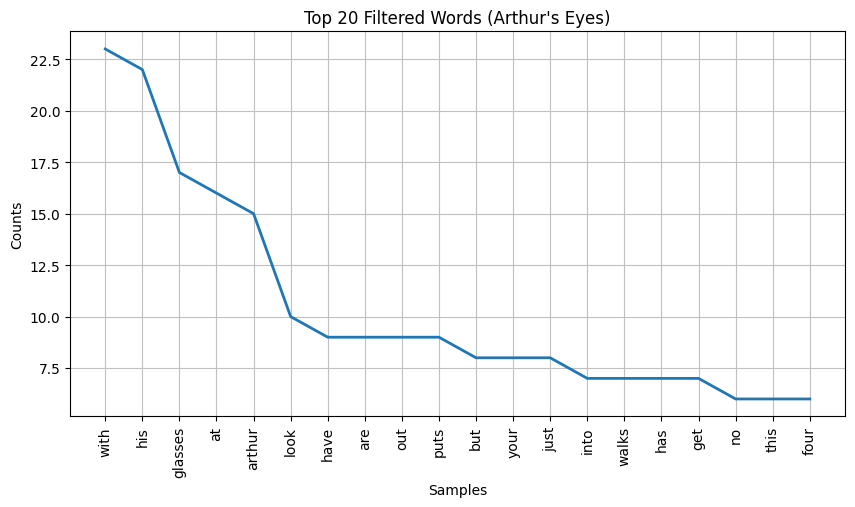

In [28]:
# Filter out common small words for a cleaner plot
stopwords = ['the', 'a', 'and', 'to', 'in', 'of', 'i', 'it', 'is', 'you', 'was', 'on', 'he', 'she']
filtered_1 = [w for w in tokens_1 if w.isalpha() and w not in stopwords]


fdist = nltk.FreqDist(filtered_1)

# Plotting
plt.figure(figsize=(10, 5))
fdist.plot(20, title="Top 20 Filtered Words (Arthur's Eyes)")